In [1]:
import os 
import pandas as pd
pd.set_option('display.max_columns', 100)
pd.set_option('display.float_format', '{:.2f}'.format)
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
dir_name = os.path.dirname(os.getcwd())

In [3]:
data = pd.read_csv(os.path.join(dir_name, 'data/data.csv'))

## Feature Explorations

In [4]:
data.shape

(1100000, 33)

In [5]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1100000 entries, 0 to 1099999
Data columns (total 33 columns):
 #   Column          Non-Null Count    Dtype  
---  ------          --------------    -----  
 0   date            1100000 non-null  object 
 1   year            1100000 non-null  int64  
 2   month           1100000 non-null  int64  
 3   day             1100000 non-null  int64  
 4   weekofyear      1100000 non-null  int64  
 5   weekday         1100000 non-null  int64  
 6   is_weekend      1100000 non-null  int64  
 7   is_holiday      1100000 non-null  int64  
 8   temperature     1100000 non-null  float64
 9   rain_mm         1100000 non-null  float64
 10  store_id        1100000 non-null  object 
 11  country         1100000 non-null  object 
 12  city            1100000 non-null  object 
 13  channel         1100000 non-null  object 
 14  latitude        1100000 non-null  float64
 15  longitude       1100000 non-null  float64
 16  sku_id          1100000 non-null  ob

In [6]:
data.isnull().sum()

date              0
year              0
month             0
day               0
weekofyear        0
weekday           0
is_weekend        0
is_holiday        0
temperature       0
rain_mm           0
store_id          0
country           0
city              0
channel           0
latitude          0
longitude         0
sku_id            0
sku_name          0
category          0
subcategory       0
brand             0
units_sold        0
list_price        0
discount_pct      0
promo_flag        0
gross_sales       0
net_sales         0
stock_on_hand     0
stock_out_flag    0
lead_time_days    0
supplier_id       0
purchase_cost     0
margin_pct        0
dtype: int64

In [7]:
data.head(7)

,date,year,month,day,weekofyear,weekday,is_weekend,is_holiday,temperature,rain_mm,store_id,country,city,channel,latitude,longitude,sku_id,sku_name,category,subcategory,brand,units_sold,list_price,discount_pct,promo_flag,gross_sales,net_sales,stock_on_hand,stock_out_flag,lead_time_days,supplier_id,purchase_cost,margin_pct
0,2021-01-01,2021,1,1,53,4,0,1,8.44,1.24,STORE0001,Germany,Berlin,Hypermarket,52.53,13.39,SKU0086,BrandB Shampoo,Personal Care,Shampoo,BrandB,16,10.49,0.10,1,167.84,151.06,248,0,11,S008,7.53,0.18
1,2021-01-02,2021,1,2,53,5,1,0,12.61,1.12,STORE0001,Germany,Berlin,Hypermarket,52.53,13.39,SKU0086,BrandB Shampoo,Personal Care,Shampoo,BrandB,12,10.49,0.00,0,125.88,125.88,238,0,6,S057,5.19,0.51
2,2021-01-03,2021,1,3,53,6,1,0,12.02,2.69,STORE0001,Germany,Berlin,Hypermarket,52.53,13.39,SKU0086,BrandB Shampoo,Personal Care,Shampoo,BrandB,38,10.49,0.30,1,398.62,279.03,238,0,6,S017,5.59,0.17
3,2021-01-04,2021,1,4,1,0,0,0,7.76,4.65,STORE0001,Germany,Berlin,Hypermarket,52.53,13.39,SKU0086,BrandB Shampoo,Personal Care,Shampoo,BrandB,8,10.49,0.00,0,83.92,83.92,216,0,7,S012,7.81,0.26
4,2021-01-05,2021,1,5,1,1,0,0,11.16,1.77,STORE0001,Germany,Berlin,Hypermarket,52.53,13.39,SKU0086,BrandB Shampoo,Personal Care,Shampoo,BrandB,17,10.49,0.20,1,178.33,142.66,372,0,8,S038,7.62,0.07
5,2021-01-06,2021,1,6,1,2,0,0,13.29,1.46,STORE0001,Germany,Berlin,Hypermarket,52.53,13.39,SKU0086,BrandB Shampoo,Personal Care,Shampoo,BrandB,11,10.49,0.00,0,115.39,115.39,353,0,4,S017,5.35,0.49
6,2021-01-07,2021,1,7,1,3,0,0,6.19,11.58,STORE0001,Germany,Berlin,Hypermarket,52.53,13.39,SKU0086,BrandB Shampoo,Personal Care,Shampoo,BrandB,15,10.49,0.20,1,157.35,125.88,183,0,9,S003,7.19,0.12


In [8]:
data['date'].min(), data['date'].max()

('2021-01-01', '2023-12-31')

In [9]:
data['country'].nunique(), data['city'].nunique(), data['store_id'].nunique(), data['sku_id'].nunique()

(7, 9, 13, 102)

In [10]:
data.groupby('country')['city'].value_counts().to_frame()

count
country     city             
Austria     Vienna      87600
France      Paris       87600
Germany     Berlin     175200
Italy       Milan      175200
            Rome       175200
Netherlands Amsterdam   48800
Poland      Warsaw      87600
Spain       Barcelona  175200
            Madrid      87600

In [11]:
data['channel'].value_counts()

channel
Hypermarket    525600
Supermarket    262800
E-commerce     262800
Convenience     48800
Name: count, dtype: int64

In [12]:
data['category'].value_counts(),data['subcategory'].value_counts()

(category
 Beverages        266085
 Snacks           261705
 Personal Care    199290
 Dairy            196005
 Home Care        176915
 Name: count, dtype: int64,
 subcategory
 Soda            71175
 Shampoo         70080
 Toothpaste      70080
 Cheese          68985
 Milk            67890
 Biscuits        67890
 Water           66795
 Chips           66795
 Juice           65700
 Chocolate       64605
 Softener        63035
 Energy drink    62415
 Nuts            62415
 Yogurt          59130
 Detergent       59130
 Soap            59130
 Cleaner         54750
 Name: count, dtype: int64)

In [13]:
data['brand'].value_counts()

brand
BrandF    187245
BrandB    186150
BrandD    186150
BrandA    182390
BrandC    180675
BrandE    177390
Name: count, dtype: int64

In [14]:
data.groupby(['store_id', 'sku_id']).size().reset_index().rename(columns={0: 'count'})

,store_id,sku_id,count
0,STORE0001,SKU0001,1095
1,STORE0001,SKU0002,1095
2,STORE0001,SKU0004,1095
3,STORE0001,SKU0006,1095
4,STORE0001,SKU0007,1095
...,...,...,...
1000,STORE0013,SKU0090,1095
1001,STORE0013,SKU0096,1095
1002,STORE0013,SKU0097,1095
1003,STORE0013,SKU0099,1095


In [15]:
(data.groupby(['store_id', 'sku_id'])
    .size()
    .reset_index()
    .rename(columns={0: 'count'})
    .sort_values(by='count', ascending=True)
)

,store_id,sku_id,count
992,STORE0013,SKU0073,620
0,STORE0001,SKU0001,1095
661,STORE0009,SKU0027,1095
662,STORE0009,SKU0028,1095
663,STORE0009,SKU0030,1095
...,...,...,...
340,STORE0005,SKU0023,1095
341,STORE0005,SKU0026,1095
342,STORE0005,SKU0027,1095
329,STORE0005,SKU0011,1095


In [16]:
data[(data['store_id']=='STORE0001')
    & (data['sku_id']=='SKU0086')
]['is_holiday'].value_counts()

is_holiday
0    1080
1      15
Name: count, dtype: int64

In [17]:
data[(data['store_id']=='STORE0001')
    & (data['sku_id']=='SKU0086')
]['is_weekend'].value_counts()

is_weekend
0    781
1    314
Name: count, dtype: int64

In [18]:
data['temperature'].describe(percentiles=[0.01, 0.05, 0.1, 0.25, 0.5, 0.75, 0.9, 0.95, 0.99])

count   1100000.00
mean         12.82
std           3.37
min           1.80
1%            4.89
5%            7.25
10%           8.32
25%          10.61
50%          12.84
75%          15.00
90%          17.22
95%          18.53
99%          20.34
max          22.83
Name: temperature, dtype: float64

In [19]:
pd.set_option('display.float_format', '{:.2f}'.format)
data.groupby('country')['temperature'].describe()

,count,mean,std,min,25%,50%,75%,max
country,,,,,,,,
Austria,87600.00,12.81,3.37,1.80,10.61,12.84,15.00,22.83
France,87600.00,12.81,3.37,1.80,10.61,12.84,15.00,22.83
Germany,175200.00,12.81,3.37,1.80,10.61,12.84,15.00,22.83
Italy,350400.00,12.81,3.37,1.80,10.61,12.84,15.00,22.83
Netherlands,48800.00,12.82,3.37,1.80,10.61,12.84,15.00,22.83
Poland,87600.00,12.81,3.37,1.80,10.61,12.84,15.00,22.83
Spain,262800.00,12.81,3.37,1.80,10.61,12.84,15.00,22.83


In [20]:
data.groupby('city')['temperature'].describe()

,count,mean,std,min,25%,50%,75%,max
city,,,,,,,,
Amsterdam,48800.00,12.82,3.37,1.80,10.61,12.84,15.00,22.83
Barcelona,175200.00,12.81,3.37,1.80,10.61,12.84,15.00,22.83
Berlin,175200.00,12.81,3.37,1.80,10.61,12.84,15.00,22.83
Madrid,87600.00,12.81,3.37,1.80,10.61,12.84,15.00,22.83
Milan,175200.00,12.81,3.37,1.80,10.61,12.84,15.00,22.83
Paris,87600.00,12.81,3.37,1.80,10.61,12.84,15.00,22.83
Rome,175200.00,12.81,3.37,1.80,10.61,12.84,15.00,22.83
Vienna,87600.00,12.81,3.37,1.80,10.61,12.84,15.00,22.83
Warsaw,87600.00,12.81,3.37,1.80,10.61,12.84,15.00,22.83


In [21]:
data.groupby('country')['rain_mm'].describe()

,count,mean,std,min,25%,50%,75%,max
country,,,,,,,,
Austria,87600.00,2.90,2.10,0.00,1.22,2.57,4.15,11.58
France,87600.00,2.90,2.10,0.00,1.22,2.57,4.15,11.58
Germany,175200.00,2.90,2.10,0.00,1.22,2.57,4.15,11.58
Italy,350400.00,2.90,2.10,0.00,1.22,2.57,4.15,11.58
Netherlands,48800.00,2.90,2.10,0.00,1.22,2.57,4.15,11.58
Poland,87600.00,2.90,2.10,0.00,1.22,2.57,4.15,11.58
Spain,262800.00,2.90,2.10,0.00,1.22,2.57,4.15,11.58


In [22]:
data.groupby('city')['rain_mm'].describe()

,count,mean,std,min,25%,50%,75%,max
city,,,,,,,,
Amsterdam,48800.00,2.90,2.10,0.00,1.22,2.57,4.15,11.58
Barcelona,175200.00,2.90,2.10,0.00,1.22,2.57,4.15,11.58
Berlin,175200.00,2.90,2.10,0.00,1.22,2.57,4.15,11.58
Madrid,87600.00,2.90,2.10,0.00,1.22,2.57,4.15,11.58
Milan,175200.00,2.90,2.10,0.00,1.22,2.57,4.15,11.58
Paris,87600.00,2.90,2.10,0.00,1.22,2.57,4.15,11.58
Rome,175200.00,2.90,2.10,0.00,1.22,2.57,4.15,11.58
Vienna,87600.00,2.90,2.10,0.00,1.22,2.57,4.15,11.58
Warsaw,87600.00,2.90,2.10,0.00,1.22,2.57,4.15,11.58


In [23]:
data.groupby('country')['list_price'].describe()

,count,mean,std,min,25%,50%,75%,max
country,,,,,,,,
Austria,87600.00,7.80,4.18,1.10,4.30,8.06,11.35,14.80
France,87600.00,7.46,4.31,1.08,3.48,6.60,11.69,14.57
Germany,175200.00,7.89,4.29,1.08,4.54,7.21,11.80,14.80
Italy,350400.00,7.59,4.20,1.08,4.20,6.95,11.21,14.80
Netherlands,48800.00,8.01,4.42,1.08,4.19,8.17,11.81,14.57
Poland,87600.00,7.65,4.05,1.29,4.55,6.95,10.73,14.57
Spain,262800.00,7.78,4.33,1.08,4.20,7.96,11.65,14.80


In [24]:
data.groupby('country')['units_sold'].describe()

,count,mean,std,min,25%,50%,75%,max
country,,,,,,,,
Austria,87600.00,65.55,47.93,0.00,29.00,55.00,91.00,544.00
France,87600.00,68.66,50.60,0.00,30.00,57.00,96.00,601.00
Germany,175200.00,67.00,48.85,0.00,30.00,57.00,93.00,691.00
Italy,350400.00,55.26,42.29,0.00,23.00,46.00,77.00,704.00
Netherlands,48800.00,35.46,27.31,0.00,15.00,29.00,49.00,294.00
Poland,87600.00,66.90,49.07,0.00,30.00,56.00,93.00,680.00
Spain,262800.00,55.81,41.27,0.00,24.00,47.00,78.00,504.00


In [25]:
data['discount_pct'].describe(percentiles=[0.01, 0.05, 0.1, 0.25, 0.5, 0.75, 0.9, 0.95, 0.99])

count   1100000.00
mean          0.01
std           0.05
min           0.00
1%            0.00
5%            0.00
10%           0.00
25%           0.00
50%           0.00
75%           0.00
90%           0.00
95%           0.15
99%           0.30
max           0.30
Name: discount_pct, dtype: float64

In [26]:
data.groupby('promo_flag')['discount_pct'].describe()

,count,mean,std,min,25%,50%,75%,max
promo_flag,,,,,,,,
0,1011743.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
1,88257.00,0.19,0.07,0.10,0.10,0.15,0.20,0.30


In [27]:
data.groupby('country')['gross_sales'].describe()

,count,mean,std,min,25%,50%,75%,max
country,,,,,,,,
Austria,87600.00,502.50,502.60,0.00,152.44,312.23,697.15,5306.25
France,87600.00,498.07,485.24,0.00,149.15,316.22,709.08,4475.16
Germany,175200.00,518.07,504.23,0.00,159.94,341.14,718.20,5660.00
Italy,350400.00,401.34,401.48,0.00,120.96,256.62,554.13,6593.90
Netherlands,48800.00,264.11,263.48,0.00,80.22,169.32,356.70,2660.20
Poland,87600.00,496.98,480.10,0.00,163.40,328.90,676.97,5843.95
Spain,262800.00,415.83,405.32,0.00,128.80,273.70,578.20,5617.55


In [28]:
data.groupby('country')['net_sales'].describe()

,count,mean,std,min,25%,50%,75%,max
country,,,,,,,,
Austria,87600.00,491.10,480.52,0.00,150.23,308.20,684.42,4495.46
France,87600.00,486.32,467.17,0.00,147.05,310.46,695.61,3846.48
Germany,175200.00,505.28,481.24,0.00,157.93,334.95,706.44,4811.00
Italy,350400.00,391.53,384.10,0.00,119.90,251.92,544.77,5144.94
Netherlands,48800.00,256.48,248.02,0.00,78.26,166.40,349.14,2394.18
Poland,87600.00,483.85,456.51,0.00,161.28,322.00,662.42,4630.59
Spain,262800.00,406.03,387.66,0.00,126.56,269.44,567.00,4494.04


In [29]:
data['stock_on_hand'].describe()

count   1100000.00
mean        299.48
std          80.07
min           0.00
25%         245.00
50%         300.00
75%         354.00
max         698.00
Name: stock_on_hand, dtype: float64

In [30]:
data['stock_out_flag'].value_counts()

stock_out_flag
0    1066886
1      33114
Name: count, dtype: int64

In [31]:
data.groupby('sku_id')['stock_out_flag'].value_counts().to_frame()

count
sku_id  stock_out_flag       
SKU0001 0               13838
        1                 397
SKU0002 0               10627
        1                 323
SKU0003 0               10638
...                       ...
SKU0100 1                 351
SKU0101 0               11669
        1                 376
SKU0102 0                9578
        1                 277

[204 rows x 1 columns]

In [32]:
data.groupby('country')['stock_out_flag'].value_counts(normalize=True).to_frame()

proportion
country     stock_out_flag            
Austria     0                     0.97
            1                     0.03
France      0                     0.97
            1                     0.03
Germany     0                     0.97
            1                     0.03
Italy       0                     0.97
            1                     0.03
Netherlands 0                     0.97
            1                     0.03
Poland      0                     0.97
            1                     0.03
Spain       0                     0.97
            1                     0.03

In [33]:
data['purchase_cost'].describe()

count   1100000.00
mean          4.63
std           2.66
min           0.49
25%           2.40
50%           4.35
75%           6.77
max          11.10
Name: purchase_cost, dtype: float64

In [34]:
data['supplier_id'].nunique()

60

In [35]:
data.groupby('supplier_id')['purchase_cost'].describe()

,count,mean,std,min,25%,50%,75%,max
supplier_id,,,,,,,,
S001,18437.00,4.63,2.67,0.49,2.41,4.36,6.81,11.10
S002,18183.00,4.65,2.68,0.49,2.39,4.39,6.83,11.09
S003,18266.00,4.62,2.66,0.49,2.40,4.35,6.78,11.09
S004,18448.00,4.62,2.65,0.49,2.42,4.34,6.75,11.08
S005,18437.00,4.64,2.66,0.49,2.39,4.39,6.79,11.09
S006,18396.00,4.62,2.65,0.49,2.42,4.35,6.74,11.10
S007,18481.00,4.64,2.67,0.49,2.38,4.42,6.78,11.10
S008,18408.00,4.64,2.65,0.49,2.42,4.39,6.76,11.10
S009,18345.00,4.61,2.66,0.49,2.39,4.32,6.74,11.08


In [36]:
data['margin_pct'].describe()

count   1100000.00
mean          0.39
std           0.10
min          -0.05
25%           0.31
50%           0.39
75%           0.47
max           0.55
Name: margin_pct, dtype: float64

In [37]:
data.groupby(['store_id','sku_id'])['units_sold'].describe()

count   mean   std  min    25%    50%    75%    max
store_id  sku_id                                                       
STORE0001 SKU0001 1095.00 146.42 72.80 1.00 102.00 131.00 176.50 582.00
          SKU0002 1095.00  82.16 33.56 0.00  61.00  79.00 100.00 218.00
          SKU0004 1095.00 114.24 44.29 0.00  83.00 110.00 139.00 261.00
          SKU0006 1095.00 147.47 74.91 0.00  98.00 132.00 182.00 627.00
          SKU0007 1095.00  33.26 14.06 0.00  24.00  32.00  41.00  92.00
...                   ...    ...   ...  ...    ...    ...    ...    ...
STORE0013 SKU0090 1095.00  11.19  3.92 0.00   9.00  11.00  14.00  25.00
          SKU0096 1095.00  51.83 18.09 0.00  41.00  53.00  64.00  99.00
          SKU0097 1095.00  38.16 13.20 0.00  30.00  38.00  47.00  78.00
          SKU0099 1095.00  61.33 30.14 0.00  43.00  56.00  74.00 226.00
          SKU0102 1095.00  60.05 28.65 0.00  42.00  57.00  73.00 202.00

[1005 rows x 8 columns]

### Observations

1. 3 years of data from 2021 to 2023
2. 7 countries, 9 cities, 13 stores, 102 SKUs
3. 4 different channels (hypermarket, supermarker, ecommerce, convenience)
4. 5 different categories, 17 different subcategories, 6 different brands
5. Strangely, median rain and temperature values are very similar across countries and cities
6. On promo days, discounts range minimum from 10% to maximum 30%
7. 60 different suppliers available
8. Low and high margin products are available 

## Data Understanding

In [38]:
data['date'] = pd.to_datetime(data['date'])
data = data.sort_values(['store_id', 'sku_id', 'date']).reset_index(drop=True)
print(f"Date range: {data['date'].min().date()} to {data['date'].max().date()}")
print(f"Series (store x SKU): {data.groupby(['store_id','sku_id']).ngroups:,} store + sku combinations")

Date range: 2021-01-01 to 2023-12-31
Series (store x SKU): 1,005 store + sku combinations


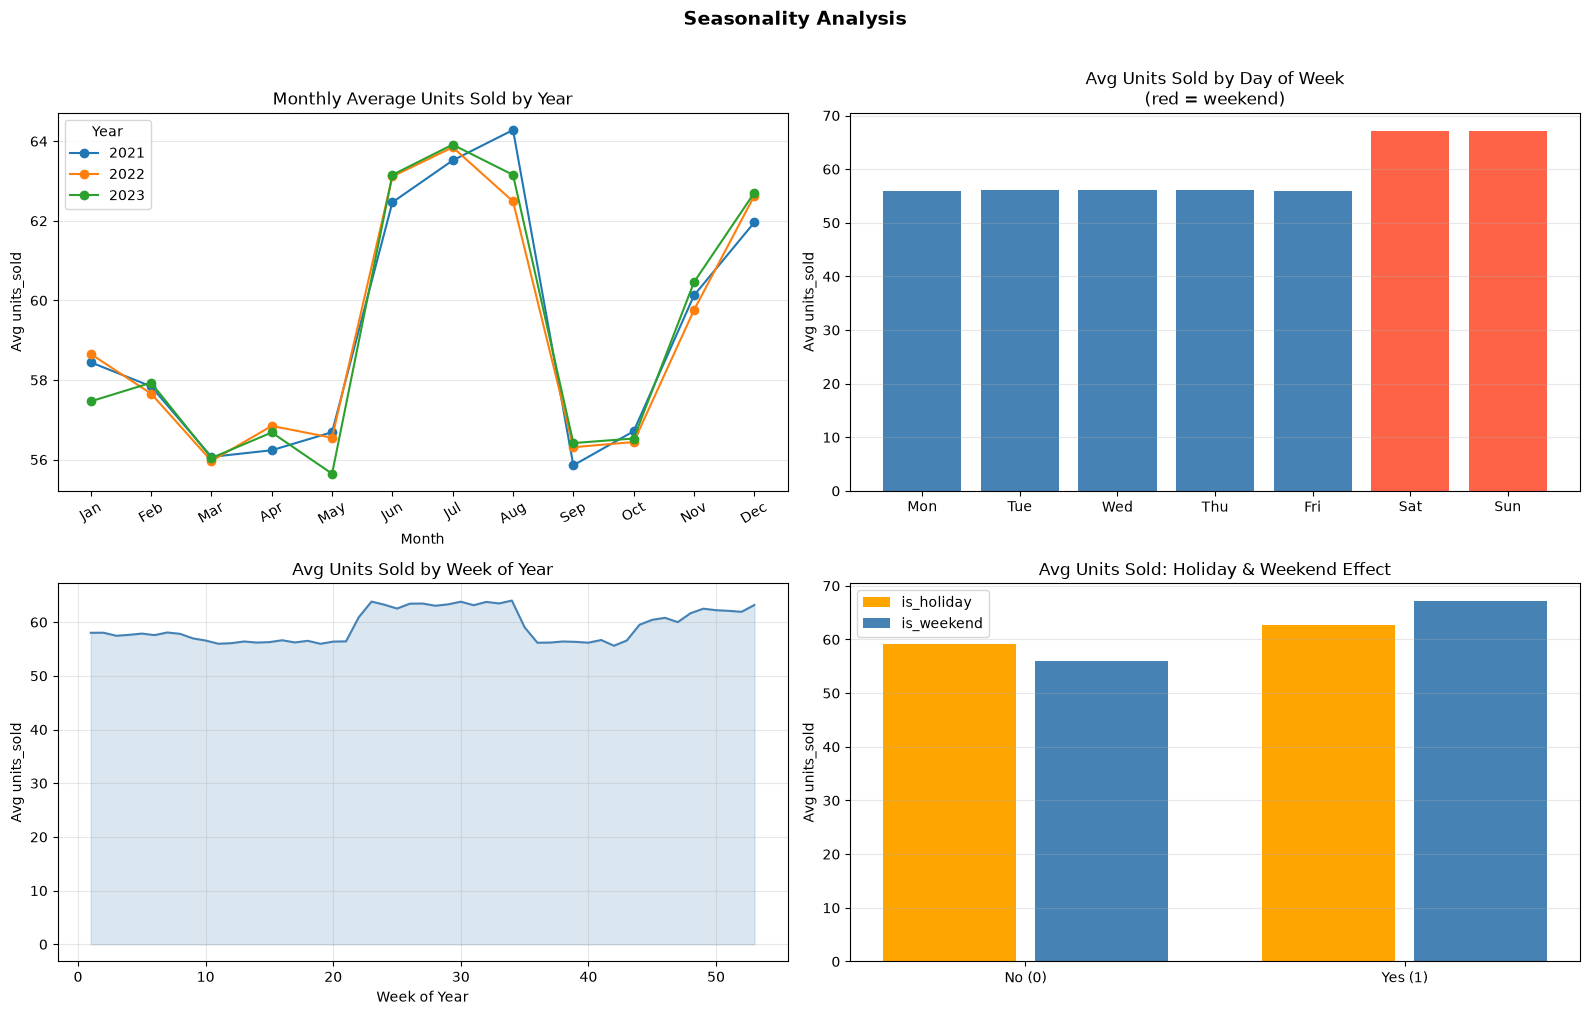

In [39]:
# ── 2.1  Seasonality: monthly, day-of-week, week-of-year, holiday/weekend ──

fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# Monthly by year
monthly = (
    data.groupby(['year', 'month'])['units_sold']
    .mean()
    .reset_index()
)
ax = axes[0, 0]
for yr, grp in monthly.groupby('year'):
    ax.plot(grp['month'], grp['units_sold'], marker='o', label=str(yr))
ax.set_title('Monthly Average Units Sold by Year')
ax.set_xlabel('Month')
ax.set_xticks(range(1, 13))
ax.set_xticklabels(['Jan','Feb','Mar','Apr','May','Jun',
                    'Jul','Aug','Sep','Oct','Nov','Dec'], rotation=30)
ax.set_ylabel('Avg units_sold')
ax.legend(title='Year')
ax.grid(axis='y', alpha=0.3)

# Day-of-week effect
dow_avg = data.groupby('weekday')['units_sold'].mean()
ax = axes[0, 1]
colors = ['tomato' if i >= 5 else 'steelblue' for i in range(7)]
ax.bar(range(7), dow_avg.values, color=colors)
ax.set_title('Avg Units Sold by Day of Week\n(red = weekend)')
ax.set_xticks(range(7))
ax.set_xticklabels(['Mon','Tue','Wed','Thu','Fri','Sat','Sun'])
ax.set_ylabel('Avg units_sold')
ax.grid(axis='y', alpha=0.3)

# Week-of-year (seasonality curve)
woy_avg = data.groupby('weekofyear')['units_sold'].mean()
ax = axes[1, 0]
ax.plot(woy_avg.index, woy_avg.values, color='steelblue')
ax.fill_between(woy_avg.index, woy_avg.values, alpha=0.2, color='steelblue')
ax.set_title('Avg Units Sold by Week of Year')
ax.set_xlabel('Week of Year')
ax.set_ylabel('Avg units_sold')
ax.grid(alpha=0.3)

# Holiday & weekend uplift
uplift = pd.DataFrame({
    'is_holiday': data.groupby('is_holiday')['units_sold'].mean(),
    'is_weekend':  data.groupby('is_weekend')['units_sold'].mean(),
})
ax = axes[1, 1]
x = np.arange(2)
ax.bar(x - 0.2, uplift['is_holiday'].values, width=0.35, label='is_holiday', color='orange')
ax.bar(x + 0.2, uplift['is_weekend'].values,  width=0.35, label='is_weekend',  color='steelblue')
ax.set_title('Avg Units Sold: Holiday & Weekend Effect')
ax.set_xticks(x)
ax.set_xticklabels(['No (0)', 'Yes (1)'])
ax.set_ylabel('Avg units_sold')
ax.legend()
ax.grid(axis='y', alpha=0.3)

plt.suptitle('Seasonality Analysis', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

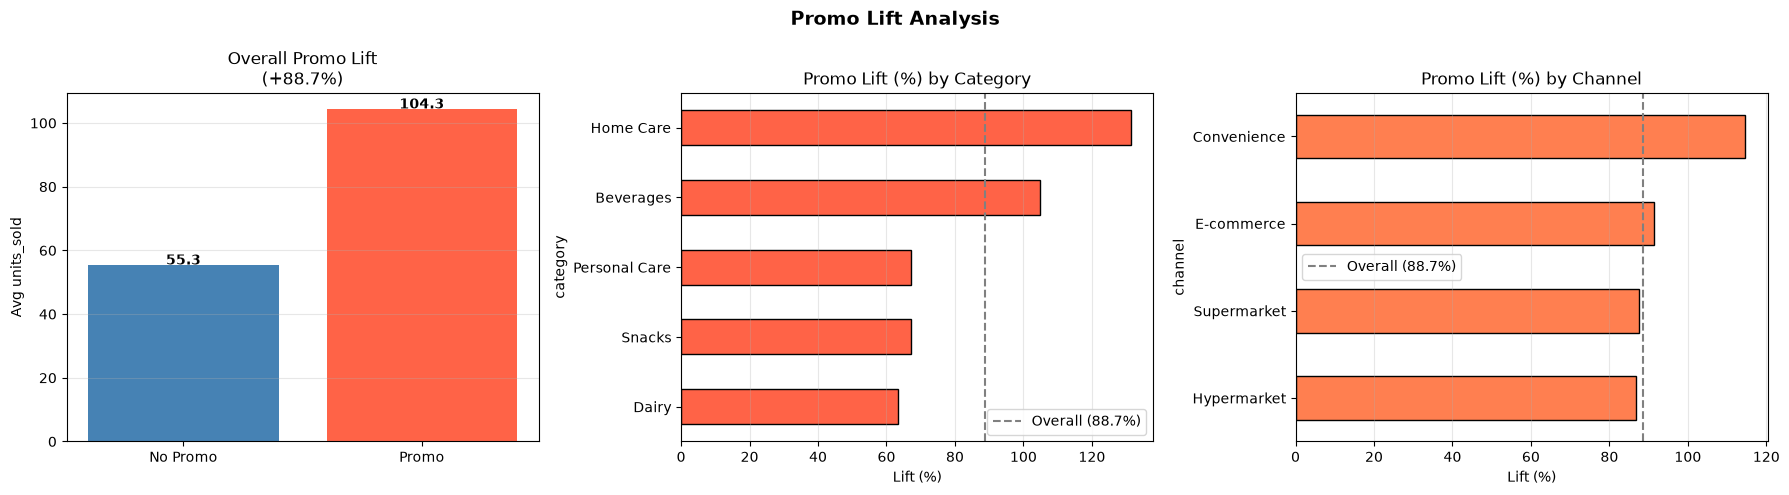


Discount depth on promo days (quantiles):
count   88257.00
mean        0.19
std         0.07
min         0.10
10%         0.10
25%         0.10
50%         0.15
75%         0.20
90%         0.30
max         0.30
Name: discount_pct, dtype: float64


In [40]:
# ── 2.2  Promo Lift ──

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Overall lift
promo_avg = data.groupby('promo_flag')['units_sold'].mean()
lift_overall = (promo_avg[1] - promo_avg[0]) / promo_avg[0] * 100

ax = axes[0]
bars = ax.bar(['No Promo', 'Promo'], promo_avg.values, color=['steelblue', 'tomato'])
for bar, val in zip(bars, promo_avg.values):
    ax.text(bar.get_x() + bar.get_width() / 2, val + 0.3,
            f'{val:.1f}', ha='center', fontweight='bold')
ax.set_title(f'Overall Promo Lift\n(+{lift_overall:.1f}%)')
ax.set_ylabel('Avg units_sold')
ax.grid(axis='y', alpha=0.3)

# Lift by category
cat_promo = data.groupby(['category', 'promo_flag'])['units_sold'].mean().unstack()
cat_lift = ((cat_promo[1] - cat_promo[0]) / cat_promo[0] * 100).sort_values()

ax = axes[1]
cat_lift.plot(kind='barh', ax=ax, color='tomato', edgecolor='black')
ax.axvline(lift_overall, linestyle='--', color='gray', label=f'Overall ({lift_overall:.1f}%)')
ax.set_title('Promo Lift (%) by Category')
ax.set_xlabel('Lift (%)')
ax.legend()
ax.grid(axis='x', alpha=0.3)

# Lift by channel
ch_promo = data.groupby(['channel', 'promo_flag'])['units_sold'].mean().unstack()
ch_lift = ((ch_promo[1] - ch_promo[0]) / ch_promo[0] * 100).sort_values()

ax = axes[2]
ch_lift.plot(kind='barh', ax=ax, color='coral', edgecolor='black')
ax.axvline(lift_overall, linestyle='--', color='gray', label=f'Overall ({lift_overall:.1f}%)')
ax.set_title('Promo Lift (%) by Channel')
ax.set_xlabel('Lift (%)')
ax.legend()
ax.grid(axis='x', alpha=0.3)

plt.suptitle('Promo Lift Analysis', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Discount distribution on promo days
print("\nDiscount depth on promo days (quantiles):")
print(data.loc[data['promo_flag'] == 1, 'discount_pct']
      .describe(percentiles=[0.1, 0.25, 0.5, 0.75, 0.9])
      .round(3))

/Users/sushantpatil/sushant/Assignment_ML_Engineer_v3/.venv/lib/python3.11/site-packages/seaborn/categorical.py:700: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  artists = ax.bxp(**boxplot_kws)


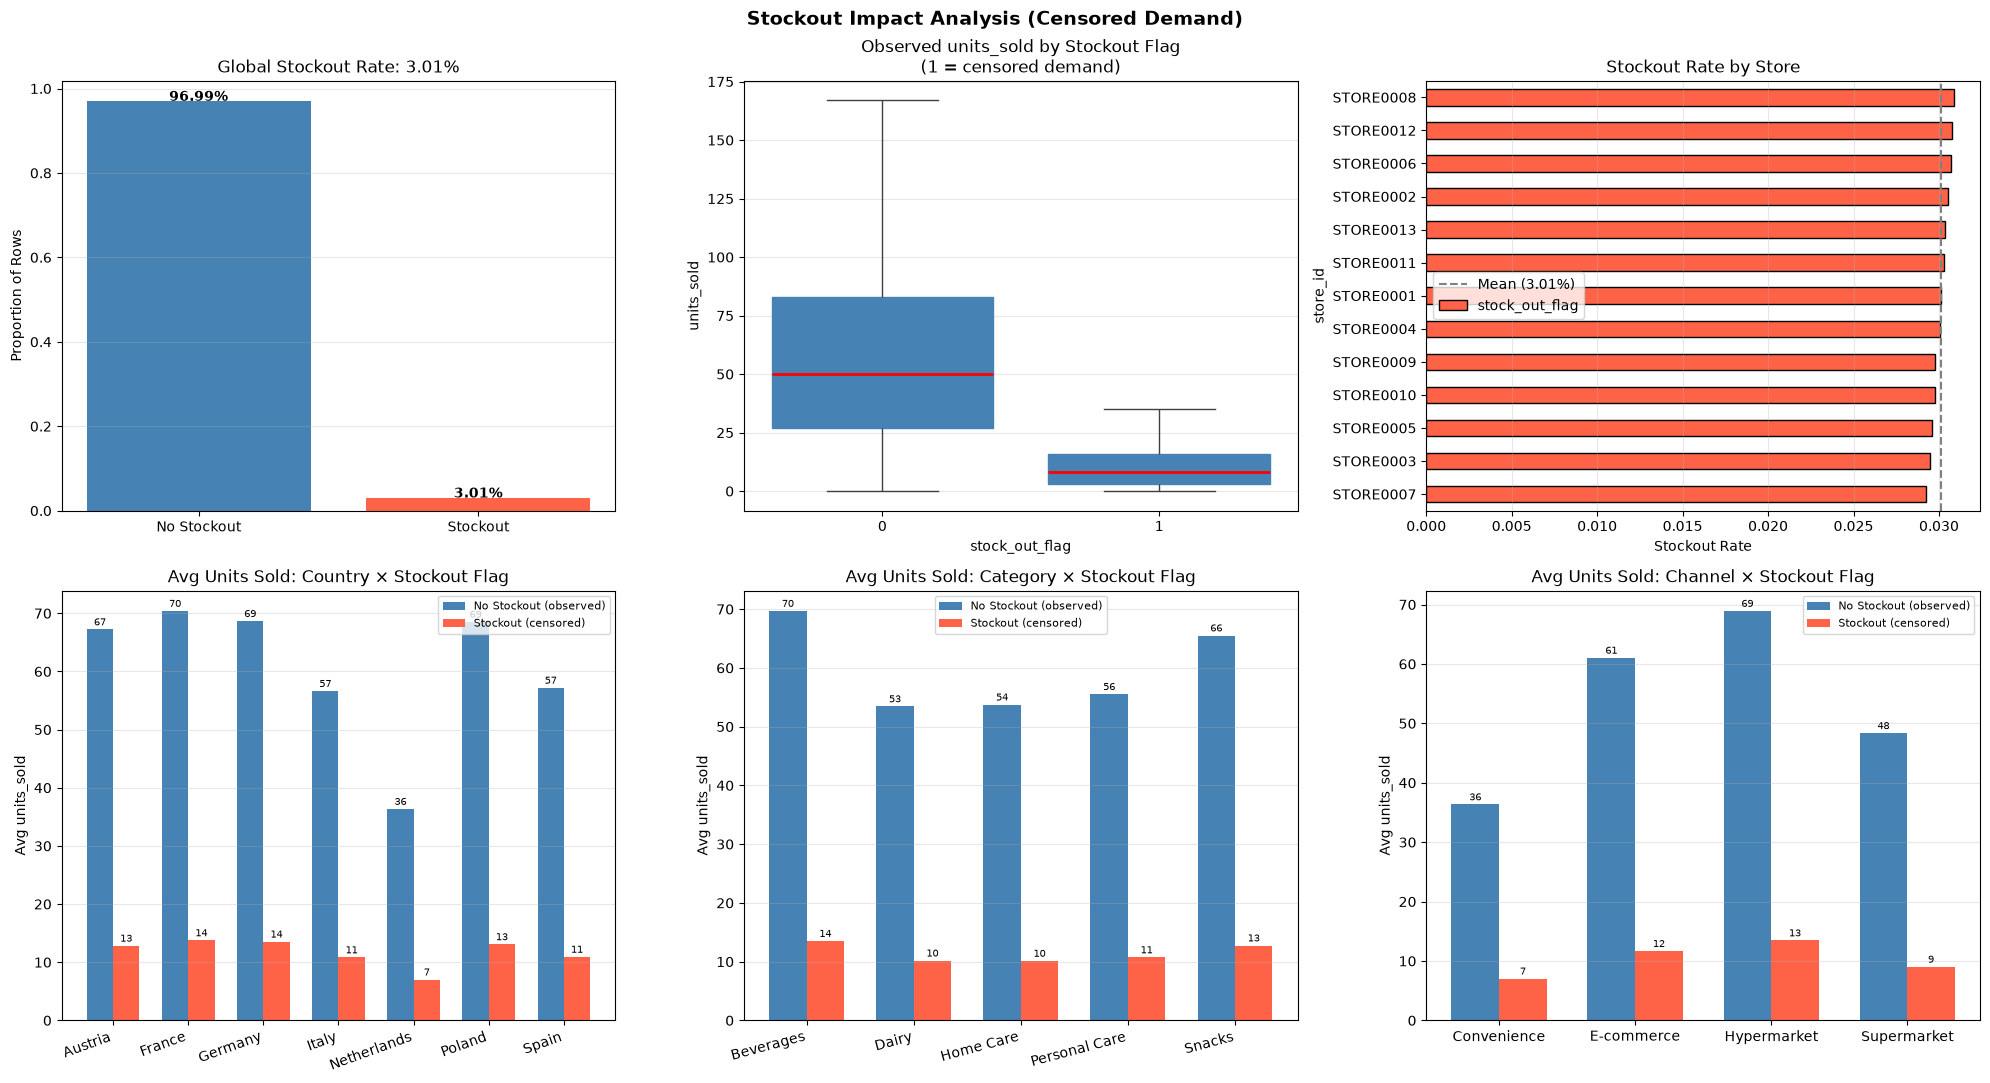

───────────────────────────────────────────────────────
Demand distribution: Stockout vs Normal
                    count  mean   std  min   25%   50%   75%    max
stock_out_flag                                                     
0              1066886.00 60.67 44.85 0.00 27.00 50.00 83.00 704.00
1                33114.00 11.69 12.57 0.00  3.00  8.00 16.00 154.00

Mean units_sold by country × stock_out_flag:
stock_out_flag     0     1
country                   
Austria        67.20 12.80
France         70.40 13.80
Germany        68.70 13.50
Italy          56.60 10.80
Netherlands    36.30  7.00
Poland         68.50 13.10
Spain          57.20 10.90

Mean units_sold by category × stock_out_flag:
stock_out_flag     0     1
category                  
Beverages      69.70 13.50
Dairy          53.40 10.20
Home Care      53.70 10.10
Personal Care  55.50 10.70
Snacks         65.50 12.70

Mean units_sold by channel × stock_out_flag:
stock_out_flag     0     1
channel                   
Conveni

In [41]:
# ── 2.3  Stockout Impact & Censored Demand ──

fig, axes = plt.subplots(2, 3, figsize=(20, 11))

# ─── Row 1: summary plots ──────────────────────────────────────────────────

# (1) Global stockout rate
so_rate = data['stock_out_flag'].mean()
ax = axes[0, 0]
ax.bar(['No Stockout', 'Stockout'],
       [1 - so_rate, so_rate], color=['steelblue', 'tomato'])
ax.set_title(f'Global Stockout Rate: {so_rate:.2%}')
ax.set_ylabel('Proportion of Rows')
for i, v in enumerate([1 - so_rate, so_rate]):
    ax.text(i, v + 0.001, f'{v:.2%}', ha='center', fontweight='bold')
ax.grid(axis='y', alpha=0.3)

# (2) Demand suppression boxplot
ax = axes[0, 1]
sns.boxplot(
    data=data, x='stock_out_flag', y='units_sold',
    showfliers=False,
    boxprops=dict(color='steelblue'),
    medianprops=dict(color='red', linewidth=2),
    ax=ax
)
ax.set_title('Observed units_sold by Stockout Flag\n(1 = censored demand)')
ax.set_xlabel('stock_out_flag')
ax.set_ylabel('units_sold')
ax.grid(axis='y', alpha=0.3)

# (3) Stockout rate by store
so_by_store = (
    data.groupby('store_id')['stock_out_flag']
    .mean()
    .sort_values(ascending=True)
)
ax = axes[0, 2]
so_by_store.plot(kind='barh', ax=ax, color='tomato', edgecolor='black')
ax.axvline(so_rate, linestyle='--', color='gray', label=f'Mean ({so_rate:.2%})')
ax.set_title('Stockout Rate by Store')
ax.set_xlabel('Stockout Rate')
ax.legend()
ax.grid(axis='x', alpha=0.3)

# ─── Row 2: mean units_sold split by stock_out_flag ───────────────────────

def plot_grouped_stockout(ax, group_col, title, rotation=0):
    """Grouped bar: mean units_sold for stock_out_flag=0 vs 1 per group."""
    pivot = (
        data.groupby([group_col, 'stock_out_flag'])['units_sold']
        .mean()
        .unstack(level='stock_out_flag')
        .rename(columns={0: 'No Stockout (observed)', 1: 'Stockout (censored)'})
    )
    x     = np.arange(len(pivot))
    width = 0.35

    bars0 = ax.bar(x - width / 2, pivot['No Stockout (observed)'],
                   width, color='steelblue', label='No Stockout (observed)')
    bars1 = ax.bar(x + width / 2, pivot['Stockout (censored)'],
                   width, color='tomato',    label='Stockout (censored)')

    ax.set_title(title)
    ax.set_xticks(x)
    ax.set_xticklabels(
        pivot.index,
        rotation=rotation,
        ha='right' if rotation else 'center'
    )
    ax.set_ylabel('Avg units_sold')
    ax.legend(fontsize=8)
    ax.grid(axis='y', alpha=0.3)

    for bar in list(bars0) + list(bars1):
        h = bar.get_height()
        ax.text(bar.get_x() + bar.get_width() / 2, h + 0.3,
                f'{h:.0f}', ha='center', va='bottom', fontsize=7)

plot_grouped_stockout(axes[1, 0], 'country',  'Avg Units Sold: Country × Stockout Flag',  rotation=20)
plot_grouped_stockout(axes[1, 1], 'category', 'Avg Units Sold: Category × Stockout Flag', rotation=15)
plot_grouped_stockout(axes[1, 2], 'channel',  'Avg Units Sold: Channel × Stockout Flag')

plt.suptitle('Stockout Impact Analysis (Censored Demand)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# ─── Tabular summary ──────────────────────────────────────────────────────
print("─" * 55)
print("Demand distribution: Stockout vs Normal")
print(data.groupby('stock_out_flag')['units_sold']
      .describe(percentiles=[0.25, 0.5, 0.75]).round(2))

for dim in ['country', 'category', 'channel']:
    print(f"\nMean units_sold by {dim} × stock_out_flag:")
    print(data.groupby([dim, 'stock_out_flag'])['units_sold']
          .mean().unstack().round(1))

print("\n⚠  units_sold when stock_out_flag=1 is CENSORED — true demand is higher.")
print("   Lags/rolling features will use NaN-imputed demand for these rows.")

In [42]:
# data.groupby('country')['stock_out_flag'].value_counts(normalize=True).to_frame()

In [43]:
# data.groupby(['country','stock_out_flag'])['units_sold'].mean()

In [44]:
# data.groupby(['category','stock_out_flag'])['units_sold'].mean()

In [45]:
# data.groupby(['channel','stock_out_flag'])['units_sold'].mean()

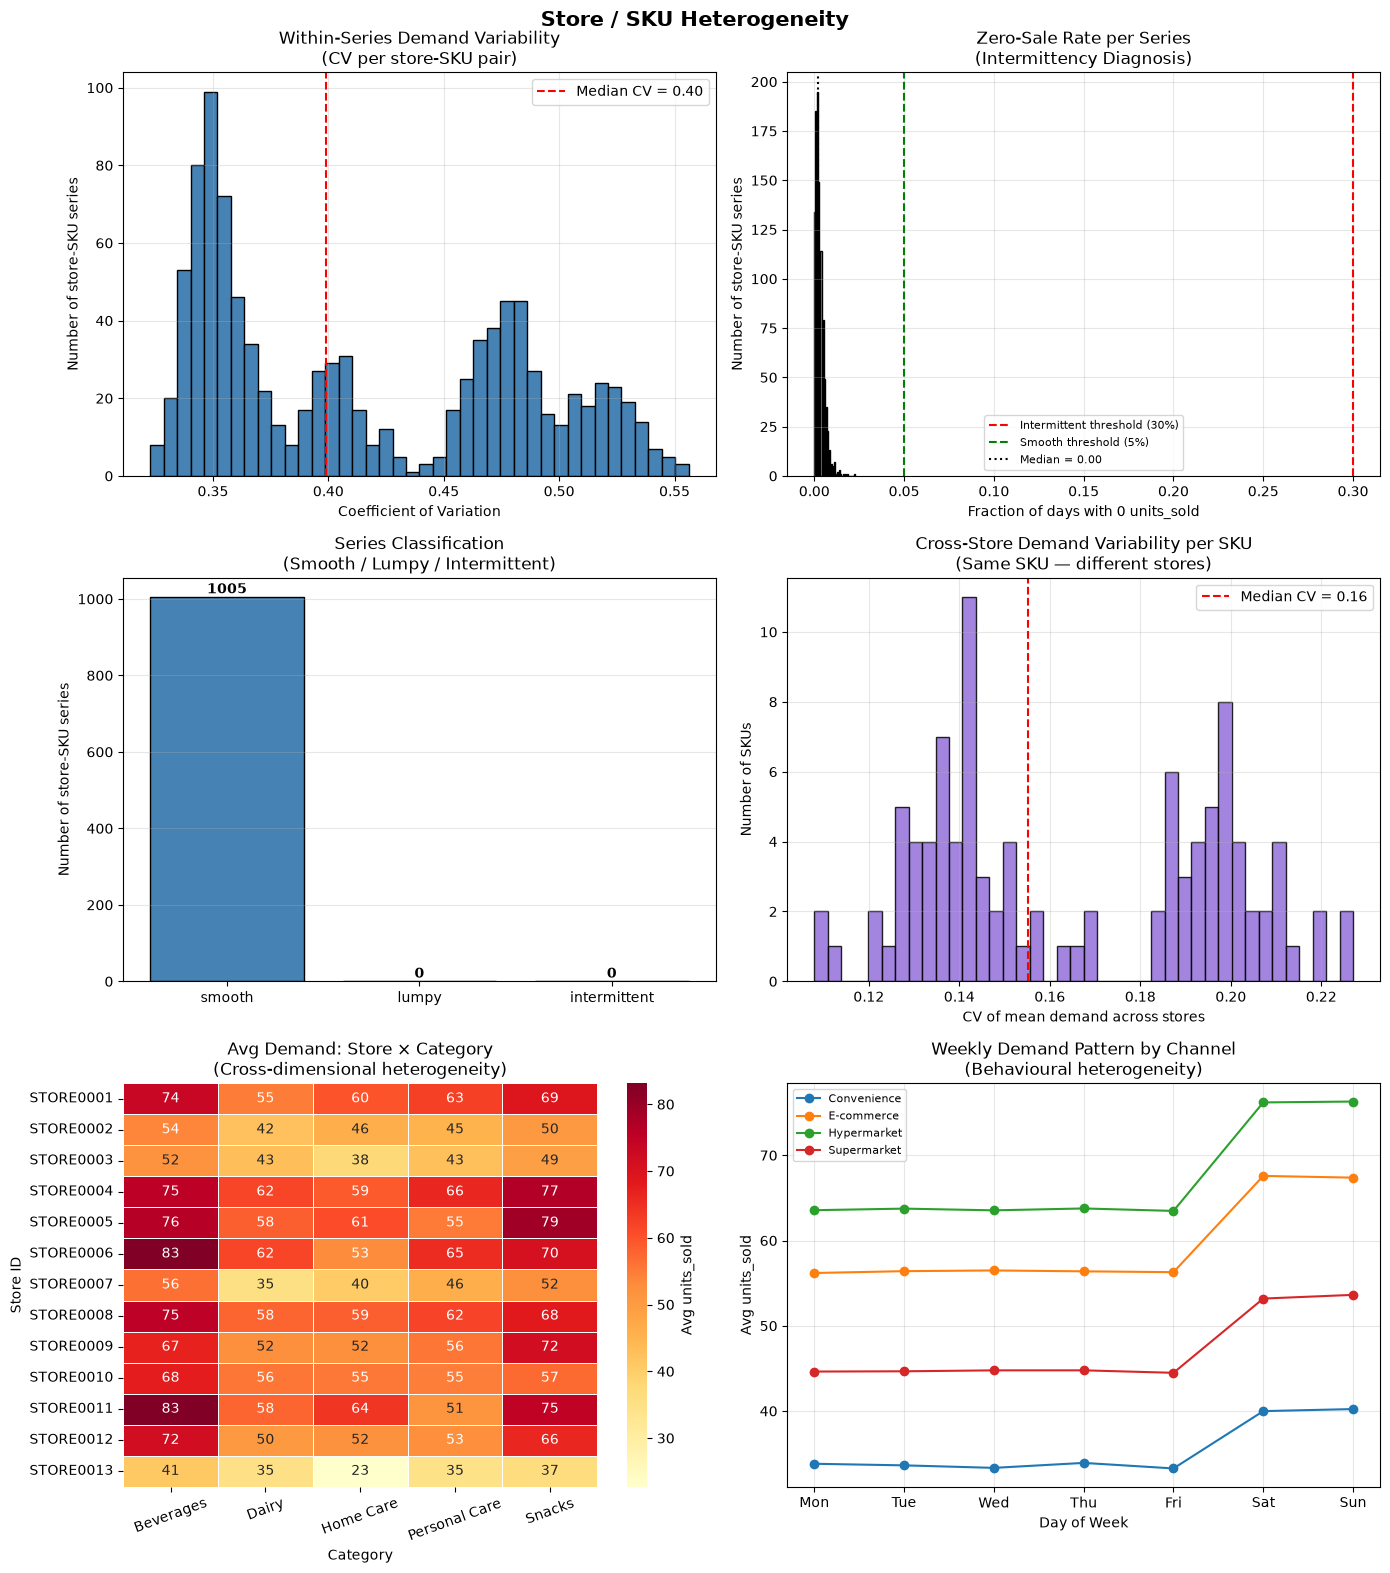

Total series: 1005

Series type breakdown:
  Smooth       (zero_rate <  5%): 1005  (100.0%)
  Lumpy        (zero_rate  5-30%):    0  (0.0%)
  Intermittent (zero_rate > 30%):    0  (0.0%)

Cold-start candidates (fill_rate < 80%): 0
Max/min demand ratio across series:      28×
Median within-series CV:                 0.40
Median cross-store SKU CV:               0.16
Median zero-sale rate:                   0.18%

Full series-level stats:
         mean     std      cv  zero_rate
count 1005.00 1005.00 1005.00    1005.00
mean    59.17   25.02    0.42       0.00
std     33.86   15.99    0.07       0.00
min      5.37    1.92    0.32       0.00
25%     29.27   11.68    0.35       0.00
50%     54.59   23.24    0.40       0.00
75%     83.63   34.05    0.48       0.00
max    149.45   78.60    0.56       0.02


In [46]:
# ── 2.4  Store / SKU Heterogeneity ──────────────────────────────────────────

# ── Series-level stats ───────────────────────────────────────────────────────
series_stats = (
    data.groupby(['store_id', 'sku_id'])['units_sold']
    .agg(
        mean='mean',
        std='std',
        count='count',
        zero_rate=lambda x: (x == 0).mean(),
    )
    .assign(cv=lambda x: x['std'] / x['mean'])
)

series_stats['series_type'] = pd.cut(
    series_stats['zero_rate'],
    bins=[-0.01, 0.05, 0.30, 1.0],
    labels=['smooth', 'lumpy', 'intermittent']
)

# ── Temporal coverage ────────────────────────────────────────────────────────
coverage = (
    data.groupby(['store_id', 'sku_id'])['date']
    .agg(first_date='min', last_date='max', obs_count='count')
    .assign(expected_days=lambda x: (x['last_date'] - x['first_date']).dt.days + 1)
    .assign(fill_rate=lambda x: x['obs_count'] / x['expected_days'])
)

# ── Cross-store SKU variance (true heterogeneity: same SKU, different stores) 
sku_cross_store = (
    data.groupby(['sku_id', 'store_id'])['units_sold']
    .mean()
    .unstack('store_id')
)
sku_cross_store_cv = (
    sku_cross_store.std(axis=1) / sku_cross_store.mean(axis=1)
).dropna()

# ── Store × Category heatmap data ────────────────────────────────────────────
heatmap_data = (
    data.groupby(['store_id', 'category'])['units_sold']
    .mean()
    .unstack('category')
)

# ── Weekly demand pattern by channel ─────────────────────────────────────────
# Assumes weekday 0=Mon … 6=Sun (standard Python convention)
weekly_channel = (
    data.groupby(['channel', 'weekday'])['units_sold']
    .mean()
    .unstack('channel')
)

# ── Plot: 3×2 grid ───────────────────────────────────────────────────────────
fig, axes = plt.subplots(3, 2, figsize=(14, 16))

# [0,0]  Within-series CV (volatility per store-SKU pair)
ax = axes[0, 0]
ax.hist(series_stats['cv'], bins=40, color='steelblue', edgecolor='black')
med_cv = series_stats['cv'].median()
ax.axvline(med_cv, color='red', linestyle='--', label=f'Median CV = {med_cv:.2f}')
ax.set_title('Within-Series Demand Variability\n(CV per store-SKU pair)')
ax.set_xlabel('Coefficient of Variation')
ax.set_ylabel('Number of store-SKU series')
ax.legend()
ax.grid(alpha=0.3)

# [0,1]  Zero-sale rate (intermittency diagnosis)
ax = axes[0, 1]
ax.hist(series_stats['zero_rate'], bins=40, color='darkorange', edgecolor='black')
med_zr = series_stats['zero_rate'].median()
ax.axvline(0.30, color='red',    linestyle='--', linewidth=1.5, label='Intermittent threshold (30%)')
ax.axvline(0.05, color='green',  linestyle='--', linewidth=1.5, label='Smooth threshold (5%)')
ax.axvline(med_zr, color='black', linestyle=':',  linewidth=1.5, label=f'Median = {med_zr:.2f}')
ax.set_title('Zero-Sale Rate per Series\n(Intermittency Diagnosis)')
ax.set_xlabel('Fraction of days with 0 units_sold')
ax.set_ylabel('Number of store-SKU series')
ax.legend(fontsize=8)
ax.grid(alpha=0.3)

# [1,0]  Series type classification counts
ax = axes[1, 0]
type_counts = (
    series_stats['series_type']
    .value_counts()
    .reindex(['smooth', 'lumpy', 'intermittent'])
)
colors = ['steelblue', 'darkorange', 'tomato']
bars = ax.bar(type_counts.index, type_counts.values, color=colors, edgecolor='black')
for bar, val in zip(bars, type_counts.values):
    ax.text(
        bar.get_x() + bar.get_width() / 2, bar.get_height() + 1,
        str(val), ha='center', va='bottom', fontweight='bold'
    )
ax.set_title('Series Classification\n(Smooth / Lumpy / Intermittent)')
ax.set_ylabel('Number of store-SKU series')
ax.grid(axis='y', alpha=0.3)

# [1,1]  Cross-store CV per SKU (does the same SKU behave uniformly across stores?)
ax = axes[1, 1]
ax.hist(sku_cross_store_cv, bins=40, color='mediumpurple', edgecolor='black', alpha=0.85)
med_cs_cv = sku_cross_store_cv.median()
ax.axvline(med_cs_cv, color='red', linestyle='--', label=f'Median CV = {med_cs_cv:.2f}')
ax.set_title('Cross-Store Demand Variability per SKU\n(Same SKU — different stores)')
ax.set_xlabel('CV of mean demand across stores')
ax.set_ylabel('Number of SKUs')
ax.legend()
ax.grid(alpha=0.3)

# [2,0]  Store × Category heatmap (cross-dimensional heterogeneity)
ax = axes[2, 0]
sns.heatmap(
    heatmap_data, annot=True, fmt='.0f', cmap='YlOrRd',
    ax=ax, linewidths=0.5, cbar_kws={'label': 'Avg units_sold'}
)
ax.set_title('Avg Demand: Store × Category\n(Cross-dimensional heterogeneity)')
ax.set_xlabel('Category')
ax.set_ylabel('Store ID')
ax.tick_params(axis='x', rotation=20)
ax.tick_params(axis='y', rotation=0)

# [2,1]  Weekly pattern by channel (behavioural heterogeneity)
ax = axes[2, 1]
day_labels = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']
for channel in weekly_channel.columns:
    ax.plot(weekly_channel.index, weekly_channel[channel], marker='o', label=channel)
ax.set_xticks(range(7))
ax.set_xticklabels(day_labels)
ax.set_title('Weekly Demand Pattern by Channel\n(Behavioural heterogeneity)')
ax.set_xlabel('Day of Week')
ax.set_ylabel('Avg units_sold')
ax.legend(fontsize=8)
ax.grid(alpha=0.3)

fig.suptitle('Store / SKU Heterogeneity', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

# ── Summary numbers ──────────────────────────────────────────────────────────
n_series       = len(series_stats)
n_smooth       = (series_stats['series_type'] == 'smooth').sum()
n_lumpy        = (series_stats['series_type'] == 'lumpy').sum()
n_intermittent = (series_stats['series_type'] == 'intermittent').sum()
n_coldstart    = (coverage['fill_rate'] < 0.80).sum()
demand_ratio   = series_stats['mean'].max() / series_stats['mean'].min()

print(f"Total series: {n_series}")
print(f"\nSeries type breakdown:")
print(f"  Smooth       (zero_rate <  5%): {n_smooth:>4}  ({n_smooth/n_series*100:.1f}%)")
print(f"  Lumpy        (zero_rate  5-30%): {n_lumpy:>4}  ({n_lumpy/n_series*100:.1f}%)")
print(f"  Intermittent (zero_rate > 30%): {n_intermittent:>4}  ({n_intermittent/n_series*100:.1f}%)")
print(f"\nCold-start candidates (fill_rate < 80%): {n_coldstart}")
print(f"Max/min demand ratio across series:      {demand_ratio:.0f}×")
print(f"Median within-series CV:                 {med_cv:.2f}")
print(f"Median cross-store SKU CV:               {med_cs_cv:.2f}")
print(f"Median zero-sale rate:                   {med_zr:.2%}")

print(f"\nFull series-level stats:")
print(series_stats[['mean', 'std', 'cv', 'zero_rate']].describe().round(2))

A. Seasonality

1. Peak periods between May-Aug and around Nov-Dec
2. Higher avg. units sold during weekends
3. Higher avg. units sold during holidays 

B. Promo lift

1. Avg units sold increase by 88.7% during promos
2. Homecare and Beverage category see higher avg units sold during promos
3. Convenience and E-commerce channels see higher avg units sold during promos

C. Stockouts

1. Global stockout rate at ~3%
2. during Censored demand, median units sold drop from 50 to 8 

D. Store-SKU Heterogeneity

1. Coefficient of Variation ranges from 0.3 to 0.6 for Store-SKU units sold. >20% CV indicates high instability
2. Store Heterogeneity - Check demand profiles for same SKU across different stores, CV ~ 16%
2. Zero rates are low, typically less than 3%
3. SKU Heterogeneity - Demand profile for different categories across the same store

## Feature Engineering

In [47]:
# ============================================================
# SECTION 3 — FEATURE ENGINEERING
# ============================================================

# Reload and sort to guarantee correct lag/rolling ordering
data = pd.read_csv(os.path.join(dir_name, 'data/data.csv'))
data['date'] = pd.to_datetime(data['date'])
data = data.sort_values(['store_id', 'sku_id', 'date']).reset_index(drop=True)

SERIES_KEY = ['store_id', 'sku_id']   # grain of each time series

# Chronological order: train (oldest) → val (middle, for tuning) → test (newest, report once)
TRAIN_END = pd.Timestamp('2022-12-31')   # ~2 years of history
VAL_END   = pd.Timestamp('2023-09-30')   # 9-month validation  (tuning / early stopping)
TEST_END  = pd.Timestamp('2023-12-31')   # final 3-month test  (~6 × 14-day cycles; report on this)

train_mask = data['date'] <= TRAIN_END
val_mask   = (data['date'] > TRAIN_END) & (data['date'] <= VAL_END)
test_mask  = (data['date'] > VAL_END)   & (data['date'] <= TEST_END)

# Print in time order so the labels match reality
for name, m in [('Train', train_mask), ('Val', val_mask), ('Test', test_mask)]:
    print(f"{name:<5}: {m.sum():>7,} rows  "
          f"({data.loc[m, 'date'].min().date()} → {data.loc[m, 'date'].max().date()})")


Train: 733,540 rows  (2021-01-01 → 2022-12-31)
Val  : 274,092 rows  (2023-01-01 → 2023-09-30)
Test :  92,368 rows  (2023-10-01 → 2023-12-31)


In [48]:
# ── 3.1  Censored demand handling ─────────────────────────────────────────
# When stock_out_flag=1, units_sold reflects supply constraints, not true demand.
# demand_adj = NaN on stockout rows ensures lag/rolling features skip censored
# values — without it, lag_1 after a stockout would carry the censored units_sold.
# Stockout rows are excluded from the training set in Section 3.8 via train_mask_clean.

data['demand_adj'] = data['units_sold'].where(data['stock_out_flag'] == 0, other=np.nan)

n_censored = data['demand_adj'].isna().sum()
print(f"Censored (stockout) rows : {n_censored:,}  ({n_censored / len(data):.2%} of total)")
print(f"Observed (valid) rows    : {data['demand_adj'].notna().sum():,}")

# Training mask that excludes censored rows
# Used in 3.7 (target encoding) and 3.8 (X_train / y_train)
train_mask_clean = train_mask & (data['stock_out_flag'] == 0)
print(f"\nClean train rows (no stockout): {train_mask_clean.sum():,}")
print(f"Dropped from train           : {train_mask.sum() - train_mask_clean.sum():,}  "
      f"({(1 - train_mask_clean.sum() / train_mask.sum()):.2%} of train)")

Censored (stockout) rows : 33,114  (3.01% of total)
Observed (valid) rows    : 1,066,886

Clean train rows (no stockout): 711,391
Dropped from train           : 22,149  (3.02% of train)


In [49]:
# ── 3.2  Calendar / Holiday / Weekend Features ────────────────────────────
# Raw integers (month, day, weekday, weekofyear): used by tree models.
# Sin/cos cyclical encodings: required by the DL model — computed once here
# so both model families draw from the same feature set.
# All calendar features are known in advance (valid future covariates).

# Cyclical encoding
data["month_sin"]      = np.sin(2 * np.pi * data["month"]      / 12)
data["month_cos"]      = np.cos(2 * np.pi * data["month"]      / 12)
data["weekday_sin"]    = np.sin(2 * np.pi * data["weekday"]    / 7)
data["weekday_cos"]    = np.cos(2 * np.pi * data["weekday"]    / 7)
data["weekofyear_sin"] = np.sin(2 * np.pi * data["weekofyear"] / 53)
data["weekofyear_cos"] = np.cos(2 * np.pi * data["weekofyear"] / 53)

data["quarter"]        = data["date"].dt.quarter
data["is_month_end"]   = data["date"].dt.is_month_end.astype(int)
data["is_month_start"] = data["date"].dt.is_month_start.astype(int)

# Country-aware calendar: correct even if holidays differ by country, and the
# (country, date) key can never duplicate rows on merge.
hol = (data[["country", "date", "is_holiday"]]
       .drop_duplicates().sort_values(["country", "date"]).copy())

hol["last_holiday_date"] = (
    hol["date"].where(hol["is_holiday"] == 1).groupby(hol["country"]).ffill()
)
hol["days_since_holiday"] = (hol["date"] - hol["last_holiday_date"]).dt.days
hol["is_pre_holiday"] = hol.groupby("country")["is_holiday"].shift(-1).fillna(0).astype(int)

data = data.merge(
    hol[["country", "date", "days_since_holiday", "is_pre_holiday"]],
    on=["country", "date"], how="left"
)
data["days_since_holiday"] = data["days_since_holiday"].fillna(999)  # safety net; see note

cal_features = [
    # raw integers — tree models
    "month", "day", "weekday", "weekofyear",
    # cyclical encodings — DL model
    "month_sin", "month_cos", "weekday_sin", "weekday_cos",
    "weekofyear_sin", "weekofyear_cos",
    # computed
    "quarter", "is_month_end", "is_month_start",
    "is_holiday", "is_weekend", "is_pre_holiday", "days_since_holiday",
]
print(f"Calendar features ({len(cal_features)}): {cal_features}")

Calendar features (17): ['month', 'day', 'weekday', 'weekofyear', 'month_sin', 'month_cos', 'weekday_sin', 'weekday_cos', 'weekofyear_sin', 'weekofyear_cos', 'quarter', 'is_month_end', 'is_month_start', 'is_holiday', 'is_weekend', 'is_pre_holiday', 'days_since_holiday']


In [50]:
# ── 3.3  Lag & Rolling Demand Features ───────────────────────────────────
#
# LEAKAGE RULE: all features are computed within (store_id, sku_id) groups
# after sorting by date.
#
# HORIZON SAFETY (14-day forecast):
#   At inference the model predicts days t+1 … t+14 in a single pass.
#   A feature is horizon-safe if it never requires a value from inside
#   the forecast window [t+1, …, t+14].
#
#   Lags:    lag_k at forecast step s requires demand at t+s-k.
#            Safe iff k >= HORIZON.
#            → lag_14 and lag_28 kept; lag_1 and lag_7 dropped.
#
#   Rolling: rolling_w with shift(n) covers [t+s-n-w+1, …, t+s-n].
#            Safe iff n >= HORIZON.
#            → All rolling features use shift(HORIZON), not shift(1).

HORIZON = 14  # fixed forecast horizon; drives all shift offsets below


def _rolling_transform(series_col, shift_n, window, agg='mean', min_p=None):
    """
    Groupby rolling with explicit shift for leakage prevention.
    Asserts shift_n >= HORIZON so no future value leaks into any
    step of the forecast window.
    """
    assert shift_n >= HORIZON, (
        f"shift_n={shift_n} exposes future data for a {HORIZON}-day horizon"
    )
    min_periods = min_p if min_p is not None else max(1, window // 2)
    agg_fns = {
        'mean': lambda x: x.shift(shift_n).rolling(window, min_periods=min_periods).mean(),
        'std':  lambda x: x.shift(shift_n).rolling(window, min_periods=min_periods).std(),
        'max':  lambda x: x.shift(shift_n).rolling(window, min_periods=min_periods).max(),
        'min':  lambda x: x.shift(shift_n).rolling(window, min_periods=min_periods).min(),
    }
    return data.groupby(SERIES_KEY)[series_col].transform(agg_fns[agg])


# ── Point-in-time lags ────────────────────────────────────────────────────
# lag_14: at the last forecast step (t+14), reads demand at t (last known). ✓
# lag_28: at the last forecast step (t+14), reads demand at t-14.           ✓
# lag_1 and lag_7 are intentionally excluded — they require values inside
# the forecast window for steps 1–13 and 1–7 respectively.

for lag in [14, 28]:
    data[f'lag_{lag}'] = data.groupby(SERIES_KEY)['demand_adj'].transform(
        lambda x, l=lag: x.shift(l)
    )

# ── Rolling statistics ────────────────────────────────────────────────────
# shift_n = HORIZON = 14. For any step s in [1, 14] the window
# [t+s-14-w+1, …, t+s-14] is entirely historical.

for window in [7, 14, 28]:
    data[f'rolling_mean_{window}'] = _rolling_transform('demand_adj', HORIZON, window, 'mean')
    data[f'rolling_std_{window}']  = _rolling_transform('demand_adj', HORIZON, window, 'std')

data['rolling_max_7'] = _rolling_transform('demand_adj', HORIZON, 7, 'max', min_p=4)
data['rolling_min_7'] = _rolling_transform('demand_adj', HORIZON, 7, 'min', min_p=4)

# Short-term vs medium-term trend: both anchored at the same shift so
# the comparison is consistent across all forecast steps.
data['demand_trend_7v28'] = data['rolling_mean_7'] - data['rolling_mean_28']

lag_features = (
    [f'lag_{l}' for l in [14, 28]] +
    [f'rolling_mean_{w}' for w in [7, 14, 28]] +
    [f'rolling_std_{w}'  for w in [7, 14, 28]] +
    ['rolling_max_7', 'rolling_min_7', 'demand_trend_7v28']
)
print(f"Lag/rolling features ({len(lag_features)}): {lag_features}")

print("\nNaN counts per lag feature (expected to be non-zero at series starts):")
print(data[lag_features].isna().sum())

Lag/rolling features (11): ['lag_14', 'lag_28', 'rolling_mean_7', 'rolling_mean_14', 'rolling_mean_28', 'rolling_std_7', 'rolling_std_14', 'rolling_std_28', 'rolling_max_7', 'rolling_min_7', 'demand_trend_7v28']

NaN counts per lag feature (expected to be non-zero at series starts):
lag_14               46761
lag_28               60416
rolling_mean_7       16174
rolling_mean_14      20320
rolling_mean_28      27595
rolling_std_7        16174
rolling_std_14       20320
rolling_std_28       27595
rolling_max_7        17240
rolling_min_7        17240
demand_trend_7v28    27595
dtype: int64


In [ ]:
# ── 3.4  Price & Promotion Features ──────────────────────────────────────
# list_price and promo_flag are assumed KNOWN IN ADVANCE (promotional
# calendars are set weeks ahead) → valid future covariates.

# Effective (net) price
data['effective_price'] = data['list_price'] * (1 - data['discount_pct'])

# Compare like with like (net vs. net), per market, train-only.
med = (data.loc[train_mask]
       .groupby(['sku_id', 'country'])['effective_price'].median()
       .rename('sku_country_median_price'))
data = data.join(med, on=['sku_id', 'country'])
data['price_vs_sku_median'] = (data['effective_price'] / data['sku_country_median_price']).fillna(1.0)

# ── Days since last promo (leakage-free via shift(1)) ─────────────────────
def days_since_promo(g):
    # date of the most recent promo STRICTLY BEFORE today (shift(1) drops today's own promo);
    # real-date arithmetic → correct even if a series has gaps.
    last_promo = g['date'].where(g['promo_flag'] == 1).shift(1).ffill()
    return (g['date'] - last_promo).dt.days

data['days_since_promo'] = (
    data.sort_values(SERIES_KEY + ['date'])
        .groupby(SERIES_KEY, group_keys=False).apply(days_since_promo)
)
# Turn "no promo history yet" into an explicit, learnable signal instead of a hole:
data['no_prior_promo']   = data['days_since_promo'].isna().astype(int)
data['days_since_promo'] = data['days_since_promo'].fillna(999)
# add 'no_prior_promo' to promo_features

# Rolling promo density (how promotional has the recent window been?)
for window in [7, 28]:
    data[f'rolling_promo_count_{window}'] = data.groupby(SERIES_KEY)['promo_flag'].transform(
        lambda x, w=window: x.shift(1).rolling(w, min_periods=1).sum()
    )

# Lag of promo flag (was there a promo N days ago?)
for lag in [1, 7]:
    data[f'lag_promo_{lag}'] = data.groupby(SERIES_KEY)['promo_flag'].transform(
        lambda x, l=lag: x.shift(l)
    )

promo_features = [
    'effective_price', 'price_vs_sku_median', 'list_price', 'discount_pct',
    'promo_flag', 'days_since_promo', 'no_prior_promo',
    'rolling_promo_count_7', 'rolling_promo_count_28', 
    'lag_promo_1', 'lag_promo_7',
]
print(f"Price/promo features ({len(promo_features)}): {promo_features}")

/var/folders/pn/dfjjqkvs0fbb5gkry12k_6200000gn/T/ipykernel_88668/676508588.py:24: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .groupby(SERIES_KEY, group_keys=False).apply(days_since_promo)


Price/promo features (10): ['effective_price', 'price_vs_sku_median', 'list_price', 'discount_pct', 'promo_flag', 'days_since_promo', 'rolling_promo_count_7', 'rolling_promo_count_28', 'lag_promo_1', 'lag_promo_7']


In [52]:
# ── 3.5  Stockout Features ────────────────────────────────────────────────
# Omitted. Censored demand is handled upstream:
#   - demand_adj = NaN (Section 3.1) propagates censoring through lag features.
#   - train_mask_clean (Section 3.1) excludes stockout rows from training.
# At inference the 14-day stockout state is unknown, so stockout-derived features
# would require imputation, adding inference complexity for ~3% of rows.
#
# Revisit: if post-training error analysis shows systematic error on days
# immediately following a stockout, add lag_stockout_1 as a single fix.

stockout_features = []
print("Stockout features: omitted")


Stockout features: omitted


In [53]:
# ── 3.6  Weather Features ─────────────────────────────────────────────────
# temperature / rain_mm are treated as known for the forecast date
# (14-day weather forecasts are a standard planning input).
# Rolling past weather is omitted: weather drives contemporaneous FMCG effects
# (shoppers buy ice cream when it's hot today), not multi-day momentum.
# Demand momentum is already captured by rolling demand features.

data['rain_flag']       = (data['rain_mm'] > 0).astype(int)
heavy_rain_thr = data.loc[train_mask, 'rain_mm'].quantile(0.75)   # train-only threshold
data['heavy_rain_flag'] = (data['rain_mm'] >= heavy_rain_thr).astype(int)

# Temperature buckets (approximate behavioural modes for shoppers)
data['temp_bin'] = pd.cut(
    data['temperature'],
    bins=[-np.inf, 7, 12, 17, 22, np.inf],
    labels=[0, 1, 2, 3, 4]
).astype(float)

weather_features = ['temperature', 'rain_mm', 'rain_flag', 'heavy_rain_flag', 'temp_bin']
print(f"Weather features ({len(weather_features)}): {weather_features}")

Weather features (5): ['temperature', 'rain_mm', 'rain_flag', 'heavy_rain_flag', 'temp_bin']


In [54]:
# ── 3.7  Store / Category / Channel Encodings ────────────────────────────
# Label encoding  → ordinal integers (no leakage; pure cardinality mapping)
# Target encoding → mean(units_sold) per group, fitted on train_mask_clean
#                   (non-stockout training rows) to avoid biasing group means
#                   with censored demand observations.

from sklearn.preprocessing import LabelEncoder

# ── Label encoding (static; no leakage) ──────────────────────────────────
label_cols = ['store_id', 'sku_id', 'channel', 'category',
              'subcategory', 'brand', 'country', 'city']

label_encoders = {}
for col in label_cols:
    le = LabelEncoder()
    data[f'{col}_enc'] = le.fit_transform(data[col])
    label_encoders[col] = le

# ── Target encoding (train_mask_clean means — excludes stockout rows) ─────
target_enc_cols = {
    'store_id'   : 'store_target_enc',
    'sku_id'     : 'sku_target_enc',
    'channel'    : 'channel_target_enc',
    'category'   : 'category_target_enc',
    'subcategory': 'subcategory_target_enc',
}
target_enc_maps = {}
SMOOTH = 20                                            # shrink small groups toward the global mean
global_mean = data.loc[train_mask_clean, 'units_sold'].mean()

def smoothed_target_encode(col, new_col):
    stats = data.loc[train_mask_clean].groupby(col)['units_sold'].agg(['mean', 'count'])
    smooth = (stats['mean'] * stats['count'] + global_mean * SMOOTH) / (stats['count'] + SMOOTH)
    data[new_col] = data[col].map(smooth).fillna(global_mean)   # unseen → global mean
    return smooth

target_enc_maps = {new: smoothed_target_encode(col, new) for col, new in target_enc_cols.items()}

gstats = data.loc[train_mask_clean].groupby(SERIES_KEY)['units_sold'].agg(['mean', 'count'])
series_smooth = (gstats['mean'] * gstats['count'] + global_mean * SMOOTH) / (gstats['count'] + SMOOTH)
data = data.join(series_smooth.rename('series_mean_demand'), on=SERIES_KEY)
data['series_mean_demand'] = data['series_mean_demand'].fillna(global_mean)

# ── Static numeric attributes (already numeric; no encoding needed) ────────
static_numeric = [
    # 'lead_time_days', 
    'latitude', 
    'longitude', 
    # 'purchase_cost', 
    # 'margin_pct'
]

enc_features = (
    [f'{c}_enc' for c in label_cols] +
    list(target_enc_cols.values()) +
    ['series_mean_demand'] +
    static_numeric
)
print(f"Encoding/static features ({len(enc_features)}): {enc_features}")

Encoding/static features (16): ['store_id_enc', 'sku_id_enc', 'channel_enc', 'category_enc', 'subcategory_enc', 'brand_enc', 'country_enc', 'city_enc', 'store_target_enc', 'sku_target_enc', 'channel_target_enc', 'category_target_enc', 'subcategory_target_enc', 'series_mean_demand', 'latitude', 'longitude']


In [ ]:
# ── 3.8  Final Feature Matrix ─────────────────────────────────────────────
FEATURE_COLS = (
    cal_features   +   
    lag_features   +   
    promo_features +   
    weather_features + 
    enc_features       
) 

TARGET_COL = "units_sold"

print(f"Total feature count : {len(FEATURE_COLS)}")
print(f"Target              : {TARGET_COL}")

# ── Splits ────────────────────────────────────────────────────────────────
# Training: stockout rows excluded (train_mask_clean defined in 3.1)
# Val/test: all rows retained
X_train = data.loc[train_mask_clean, FEATURE_COLS]
y_train = data.loc[train_mask_clean, TARGET_COL]

X_val   = data.loc[val_mask,   FEATURE_COLS]
y_val   = data.loc[val_mask,   TARGET_COL]

X_test  = data.loc[test_mask,  FEATURE_COLS]
y_test  = data.loc[test_mask,  TARGET_COL]

print("")
print(f"X_train : {X_train.shape}  |  NaN: {X_train.isna().sum().sum():,}")
print(f"X_test  : {X_test.shape}   |  NaN: {X_test.isna().sum().sum():,}")
print(f"X_val   : {X_val.shape}    |  NaN: {X_val.isna().sum().sum():,}")

nan_summary = X_train.isna().sum()
nan_summary = nan_summary[nan_summary > 0].sort_values(ascending=False)
print("")
print("Features with NaN in X_train:")
print(nan_summary)

Total feature count : 60
Target              : units_sold

X_train : (711391, 60)  |  NaN: 276,790
X_test  : (92368, 60)   |  NaN: 5,404
X_val   : (274092, 60)    |  NaN: 16,558

Features with NaN in X_train:
lag_28                    47948
lag_14                    34684
rolling_mean_28           26761
rolling_std_28            26761
demand_trend_7v28         26761
rolling_mean_14           19694
rolling_std_14            19694
rolling_max_7             16699
rolling_min_7             16699
rolling_mean_7            15665
rolling_std_7             15665
lag_promo_7                6825
rolling_promo_count_7       978
rolling_promo_count_28      978
lag_promo_1                 978
dtype: int64
